# Detecting Bangla DeepFake Audio Using LSTM

**Reproduction Study** — Based on the paper `Detecting Bangla Deepfake Using Lstm and WaveNet` by Ayan et al. (2026)

This notebook replicates the methodology from the paper using the paper's own Bangla audio dataset. We will call it `LSTM Bangla Audio Dataset`. The dataset contains both real and deepfake audio samples in Bangla.
We implement one model: **RNN-based LSTM** using MFCC features.
The goal of this notebook is to reproduce the results reported in the paper and to provide a clear implementation of the LSTM model for Bangla deepfake audio detection.

---

## 1. Imports and Configuration

In [1]:
import os
import glob
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import IPython.display as ipd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------------
# NOTE: scikit-learn is intentionally NOT used.
# This keeps the notebook easy to run on Python 3.13 without compiling
# scikit-learn from source. We implement the few needed utilities here.
# ------------------------------------------------------------------

def stratified_split_indices(y, test_size=0.2, seed=42):
    """Return (train_idx, test_idx) with stratification by class."""
    y = np.asarray(y)
    rng = np.random.default_rng(seed)

    all_idx = np.arange(len(y))
    train_parts = []
    test_parts = []

    classes = np.unique(y)
    for cls in classes:
        cls_idx = all_idx[y == cls]
        rng.shuffle(cls_idx)

        if len(cls_idx) <= 1:
            n_test = 0
        else:
            n_test = int(round(len(cls_idx) * float(test_size)))
            n_test = max(1, min(len(cls_idx) - 1, n_test))

        test_parts.append(cls_idx[:n_test])
        train_parts.append(cls_idx[n_test:])

    test_idx = np.concatenate(test_parts) if len(test_parts) else np.array([], dtype=int)
    train_idx = np.concatenate(train_parts) if len(train_parts) else np.array([], dtype=int)

    rng.shuffle(test_idx)
    rng.shuffle(train_idx)
    return train_idx, test_idx


def confusion_matrix_np(y_true, y_pred, num_classes=2):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


def _per_class_stats_from_cm(cm):
    tp = np.diag(cm).astype(np.float64)
    fp = cm.sum(axis=0).astype(np.float64) - tp
    fn = cm.sum(axis=1).astype(np.float64) - tp
    support = cm.sum(axis=1).astype(np.float64)

    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp), where=(tp + fp) != 0)
    recall = np.divide(tp, tp + fn, out=np.zeros_like(tp), where=(tp + fn) != 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(tp), where=(precision + recall) != 0)

    return precision, recall, f1, support


def accuracy_score_np(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(y_true == y_pred))


def weighted_precision_recall_f1_np(y_true, y_pred, num_classes=2):
    cm = confusion_matrix_np(y_true, y_pred, num_classes=num_classes)
    precision, recall, f1, support = _per_class_stats_from_cm(cm)
    total = support.sum() if support.sum() > 0 else 1.0
    w = support / total
    return float((precision * w).sum()), float((recall * w).sum()), float((f1 * w).sum())


def classification_report_np(y_true, y_pred, target_names=None, digits=4):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)

    num_classes = int(max(y_true.max(initial=0), y_pred.max(initial=0)) + 1)
    if target_names is None:
        target_names = [str(i) for i in range(num_classes)]

    cm = confusion_matrix_np(y_true, y_pred, num_classes=num_classes)
    precision, recall, f1, support = _per_class_stats_from_cm(cm)

    acc = accuracy_score_np(y_true, y_pred)
    w_prec, w_rec, w_f1 = weighted_precision_recall_f1_np(y_true, y_pred, num_classes=num_classes)

    fmt = f"{{:>{digits+6}.{digits}f}}"
    lines = []
    lines.append("".ljust(16) + "precision".rjust(12) + "recall".rjust(12) + "f1-score".rjust(12) + "support".rjust(12))

    for i, name in enumerate(target_names):
        lines.append(
            name.ljust(16)
            + fmt.format(precision[i]).rjust(12)
            + fmt.format(recall[i]).rjust(12)
            + fmt.format(f1[i]).rjust(12)
            + f"{int(support[i]):12d}"
        )

    lines.append("")
    lines.append("accuracy".ljust(16) + "".rjust(12) + "".rjust(12) + fmt.format(acc).rjust(12) + f"{int(support.sum()):12d}")
    lines.append("weighted avg".ljust(16) + fmt.format(w_prec).rjust(12) + fmt.format(w_rec).rjust(12) + fmt.format(w_f1).rjust(12) + f"{int(support.sum()):12d}")

    return "\n".join(lines)


def roc_curve_np(y_true, y_score):
    """Binary ROC curve (y_true in {0,1}). Returns (fpr, tpr, thresholds)."""
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=np.float64)

    order = np.argsort(-y_score, kind="mergesort")
    y_true = y_true[order]
    y_score = y_score[order]

    distinct = np.where(np.diff(y_score))[0]
    threshold_idxs = np.r_[distinct, y_true.size - 1]

    tps = np.cumsum(y_true)[threshold_idxs]
    fps = 1 + threshold_idxs - tps

    tps = np.r_[0, tps]
    fps = np.r_[0, fps]

    P = y_true.sum()
    N = y_true.size - P

    tpr = tps / P if P > 0 else np.zeros_like(tps, dtype=np.float64)
    fpr = fps / N if N > 0 else np.zeros_like(fps, dtype=np.float64)

    thresholds = np.r_[np.inf, y_score[threshold_idxs]]
    return fpr, tpr, thresholds


def auc_np(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    return float(np.trapz(y, x))


# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

Using device: cuda


In [2]:
# ============================================================
# Configuration — adjust paths and hyperparameters here
# ============================================================
DATASET_DIR = r"./Dataset"

# Audio processing
SAMPLE_RATE      = 16000   # Paper uses 16 kHz
AUDIO_DURATION   = 5       # seconds — pad/truncate to fixed length
N_MFCC           = 40      # Number of MFCC coefficients
MAX_LEN_MFCC     = 157     # Time frames for ~5 s at 16 kHz with default hop

# Training
TEST_SIZE        = 0.20
VAL_SIZE         = 0.10    # of the remaining training set
BATCH_SIZE       = 64      # For LSTM (MFCC features are small)
LSTM_EPOCHS      = 40
LSTM_LR          = 1e-4    # Paper: 0.0001
NUM_CLASSES      = 2

print("Configuration loaded.")

Configuration loaded.


## 2. Data Loading and Exploration

In [3]:
def collect_file_paths(dataset_dir):
    """Walk through dataset directories and collect (filepath, label) pairs."""
    records = []
    for speaker_dir in sorted(os.listdir(dataset_dir)):
        speaker_path = os.path.join(dataset_dir, speaker_dir)
        if not os.path.isdir(speaker_path):
            continue
        for label_name in ["Real", "Fake"]:
            label = 0 if label_name == "Real" else 1
            folder = os.path.join(speaker_path, label_name)
            if not os.path.isdir(folder):
                continue
            wav_files = glob.glob(os.path.join(folder, "*.wav"))
            for fp in wav_files:
                records.append({
                    "filepath": fp,
                    "label": label,
                    "label_name": label_name,
                    "speaker": speaker_dir,
                })
    return pd.DataFrame(records)

df = collect_file_paths(DATASET_DIR)
print(f"Total samples: {len(df)}")
print(f"\nLabel distribution:")
print(df['label_name'].value_counts())
print(f"\nSpeaker count: {df['speaker'].nunique()}")

Total samples: 4500

Label distribution:
label_name
Real    2250
Fake    2250
Name: count, dtype: int64

Speaker count: 75


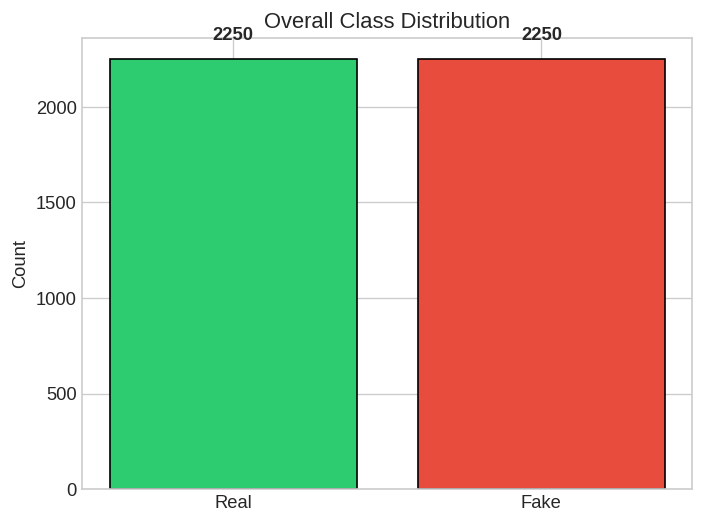

In [4]:
# --- Class distribution bar chart ---
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))

# Overall distribution
counts = df['label_name'].value_counts()
ax.bar(counts.index, counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax.set_title('Overall Class Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

## 3. Audio Visualization

In [5]:
def load_audio(filepath, sr=SAMPLE_RATE, duration=AUDIO_DURATION):
    """Load audio file, resample to target sr, pad/truncate to fixed duration."""
    y, sr_orig = librosa.load(filepath, sr=sr, duration=duration)
    target_len = sr * duration
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)), mode='constant')
    else:
        y = y[:target_len]
    return y, sr


# Pick one real and one fake sample for visualization
sample_real = df[df['label'] == 0].sample(1, random_state=SEED).iloc[0]
sample_fake = df[df['label'] == 1].sample(1, random_state=SEED).iloc[0]

y_real, _ = load_audio(sample_real['filepath'])
y_fake, _ = load_audio(sample_fake['filepath'])

print(f"Real sample: {os.path.basename(sample_real['filepath'])} (speaker: {sample_real['speaker']})")
print(f"Fake sample: {os.path.basename(sample_fake['filepath'])} (speaker: {sample_fake['speaker']})")

Real sample: 29.wav (speaker: S1F04)
Fake sample: 29.wav (speaker: S1F04)


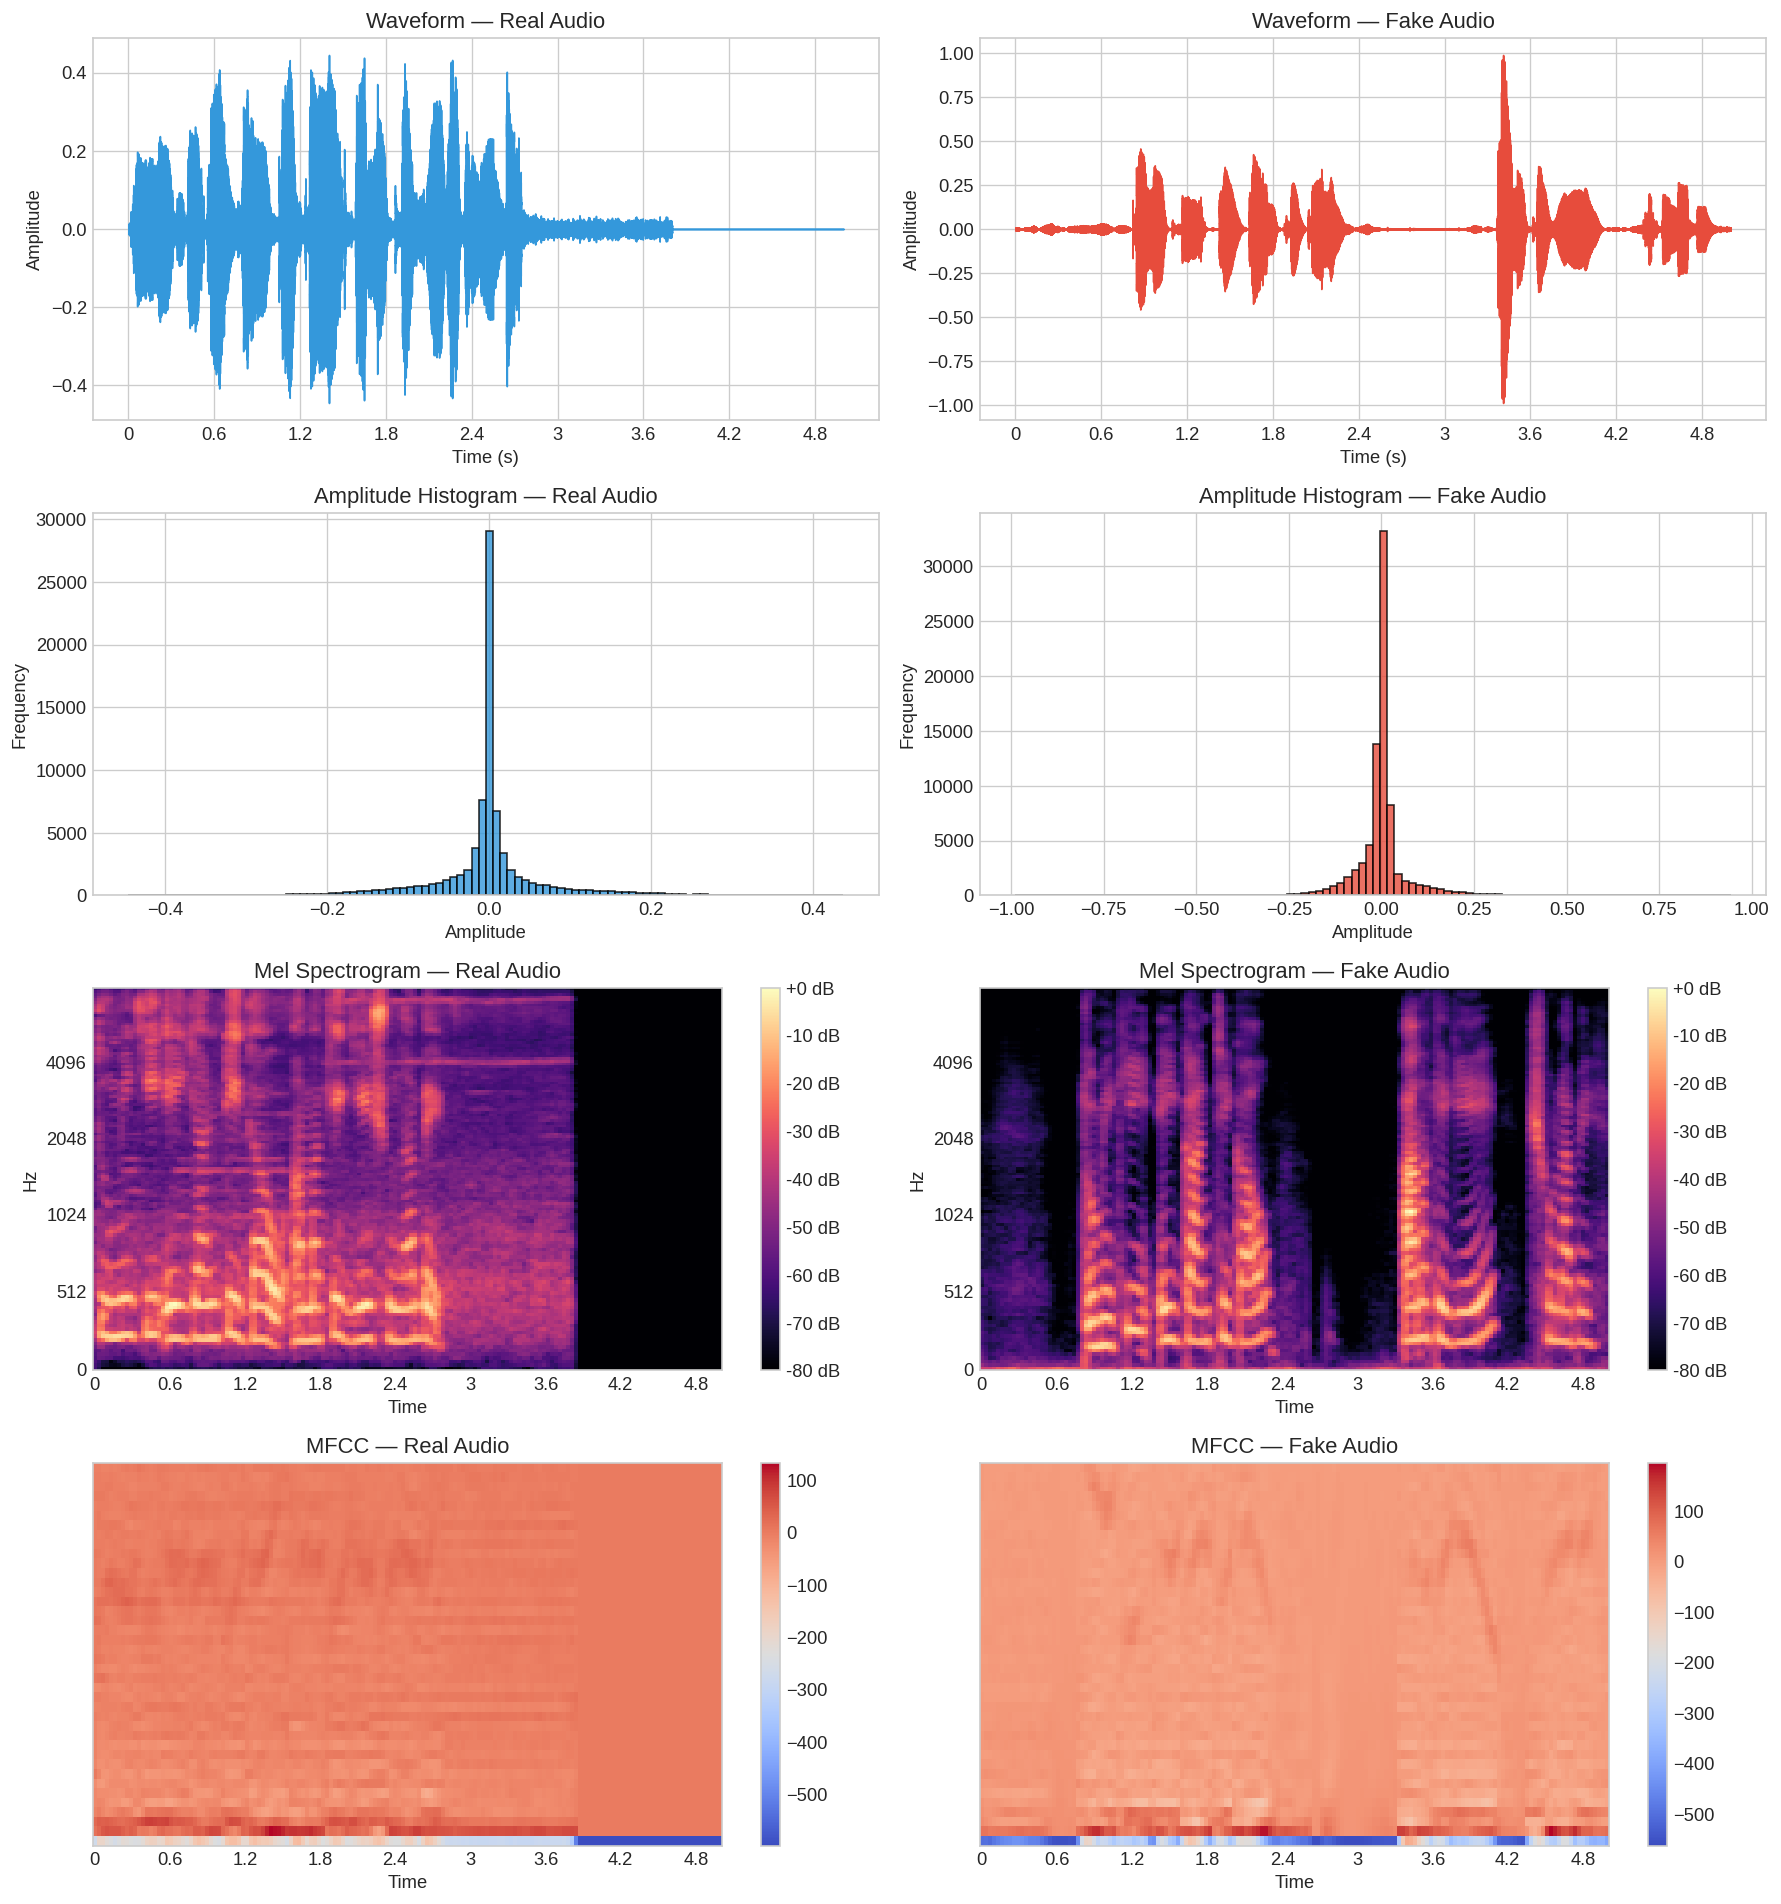

In [6]:
# --- Waveform, Histogram, Spectrogram, and MFCC for real vs. fake ---
fig, axes = plt.subplots(4, 2, figsize=(15, 16))

for col, (y, title) in enumerate([(y_real, 'Real Audio'), (y_fake, 'Fake Audio')]):
    # Waveform
    librosa.display.waveshow(y, sr=SAMPLE_RATE, ax=axes[0, col], color='#3498db' if col == 0 else '#e74c3c')
    axes[0, col].set_title(f'Waveform — {title}')
    axes[0, col].set_xlabel('Time (s)')
    axes[0, col].set_ylabel('Amplitude')

    # Histogram
    axes[1, col].hist(y, bins=100, color='#3498db' if col == 0 else '#e74c3c', alpha=0.8, edgecolor='black')
    axes[1, col].set_title(f'Amplitude Histogram — {title}')
    axes[1, col].set_xlabel('Amplitude')
    axes[1, col].set_ylabel('Frequency')

    # Mel Spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=SAMPLE_RATE, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, sr=SAMPLE_RATE, x_axis='time', y_axis='mel', ax=axes[2, col])
    axes[2, col].set_title(f'Mel Spectrogram — {title}')
    fig.colorbar(img, ax=axes[2, col], format='%+2.0f dB')

    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=SAMPLE_RATE, n_mfcc=N_MFCC)
    img2 = librosa.display.specshow(mfcc, sr=SAMPLE_RATE, x_axis='time', ax=axes[3, col])
    axes[3, col].set_title(f'MFCC — {title}')
    fig.colorbar(img2, ax=axes[3, col])

plt.tight_layout()
plt.savefig('audio_visualization.png', bbox_inches='tight')
plt.show()

In [7]:
# --- Listen to samples ---
print("Real Audio:")
ipd.display(ipd.Audio(y_real, rate=SAMPLE_RATE))
print("\nFake Audio:")
ipd.display(ipd.Audio(y_fake, rate=SAMPLE_RATE))

Real Audio:



Fake Audio:


## 4. Feature Extraction

### 4a. MFCC Features (for LSTM model)

As described in the paper, MFCC features are extracted from each audio file.
We extract **40 MFCC coefficients** per time frame and pad/truncate to a fixed number of time steps.

In [8]:
def extract_mfcc(filepath, sr=SAMPLE_RATE, duration=AUDIO_DURATION,
                 n_mfcc=N_MFCC, max_len=MAX_LEN_MFCC):
    """Extract MFCC features from an audio file."""
    y, _ = load_audio(filepath, sr=sr, duration=duration)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)  # (n_mfcc, time)
    # Pad or truncate time axis
    if mfcc.shape[1] < max_len:
        mfcc = np.pad(mfcc, ((0, 0), (0, max_len - mfcc.shape[1])), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]
    return mfcc.T  # (time, n_mfcc) — sequence-first for LSTM


# Quick test
test_mfcc = extract_mfcc(sample_real['filepath'])
print(f"MFCC shape : {test_mfcc.shape}  — (time_steps, n_mfcc)")

MFCC shape : (157, 40)  — (time_steps, n_mfcc)


In [9]:
# ============================================================
# Extract MFCC features for the full dataset
# ============================================================
print("Extracting MFCC features...")

mfcc_features = []
labels = []
valid_indices = []
valid_filepaths = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing audio"):
    try:
        mfcc = extract_mfcc(row['filepath'])
        mfcc_features.append(mfcc)
        labels.append(row['label'])
        valid_indices.append(idx)
        valid_filepaths.append(row['filepath'])
    except Exception as e:
        print(f"  Skipping {row['filepath']}: {e}")

X_mfcc = np.array(mfcc_features, dtype=np.float32)
del mfcc_features  # free the list immediately
y_all = np.array(labels, dtype=np.int64)
filepaths_all = np.array(valid_filepaths)

print(f"\nExtracted features for {len(y_all)} samples")
print(f"MFCC array shape : {X_mfcc.shape}")
print(f"Label distribution: Real={np.sum(y_all == 0)}, Fake={np.sum(y_all == 1)}")

Extracting MFCC features...


Processing audio: 100%|██████████| 4500/4500 [00:24<00:00, 180.53it/s]



Extracted features for 4500 samples
MFCC array shape : (4500, 157, 40)
Label distribution: Real=2250, Fake=2250


## 5. Stratified Train / Validation / Test Split

Following the paper's methodology, we use stratified splitting to maintain class balance across sets.

In [10]:
# --- First split: train+val vs. test (80/20), stratified ---
train_val_idx, test_idx = stratified_split_indices(y_all, test_size=TEST_SIZE, seed=SEED)

# --- Second split: train vs. val from the train+val portion, stratified ---
relative_train_idx, relative_val_idx = stratified_split_indices(y_all[train_val_idx], test_size=VAL_SIZE, seed=SEED)
train_idx = train_val_idx[relative_train_idx]
val_idx = train_val_idx[relative_val_idx]

# MFCC splits (small enough to stay in RAM: ~600 MB)
X_train_mfcc, X_val_mfcc, X_test_mfcc = X_mfcc[train_idx], X_mfcc[val_idx], X_mfcc[test_idx]
y_train, y_val, y_test = y_all[train_idx], y_all[val_idx], y_all[test_idx]

# Free the unsplit array now that we have the splits
del X_mfcc
import gc; gc.collect()

print(f"Train : {len(y_train)} samples  (Real={np.sum(y_train==0)}, Fake={np.sum(y_train==1)})")
print(f"Val   : {len(y_val)} samples  (Real={np.sum(y_val==0)}, Fake={np.sum(y_val==1)})")
print(f"Test  : {len(y_test)} samples  (Real={np.sum(y_test==0)}, Fake={np.sum(y_test==1)})")

Train : 3240 samples  (Real=1620, Fake=1620)
Val   : 360 samples  (Real=180, Fake=180)
Test  : 900 samples  (Real=450, Fake=450)


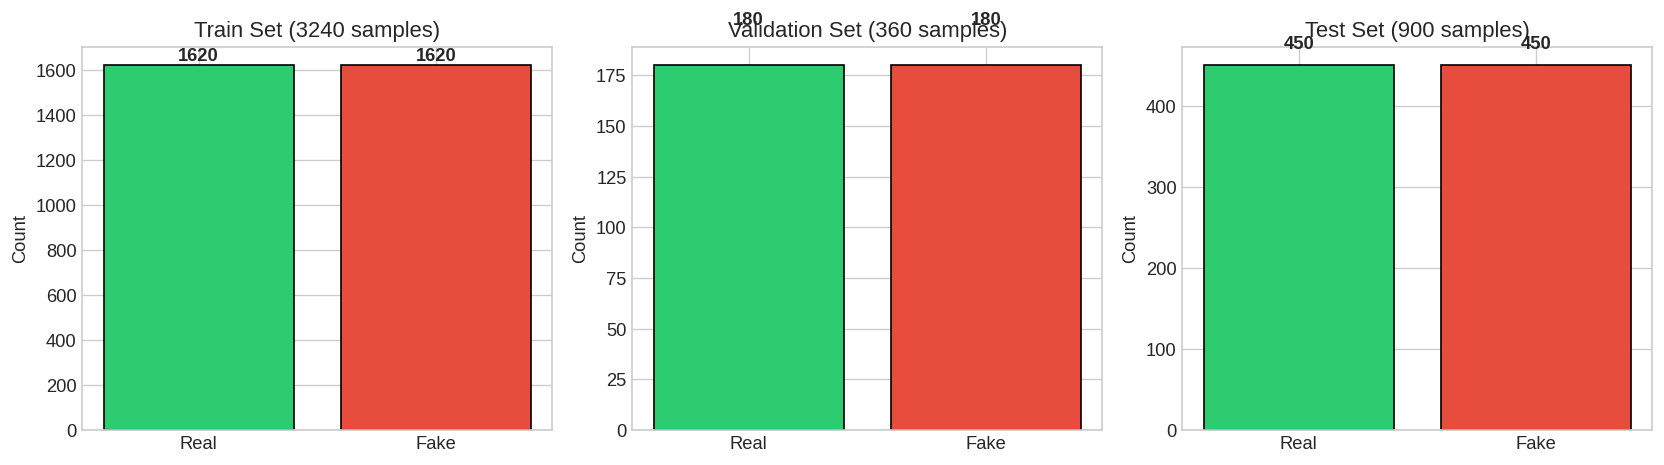

In [11]:
# --- Split distribution visualization ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (split_y, name) in zip(axes, [(y_train, 'Train'), (y_val, 'Validation'), (y_test, 'Test')]):
    unique, counts = np.unique(split_y, return_counts=True)
    label_names = ['Real', 'Fake']
    colors = ['#2ecc71', '#e74c3c']
    ax.bar(label_names, counts, color=colors, edgecolor='black')
    ax.set_title(f'{name} Set ({len(split_y)} samples)')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts):
        ax.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('split_distribution.png', bbox_inches='tight')
plt.show()

## 6. PyTorch Datasets and DataLoaders

In [12]:
class MFCCDataset(Dataset):
    """Dataset for MFCC features (LSTM model)."""
    def __init__(self, X, y):
        # Use from_numpy to share memory with the numpy array (no copy)
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# MFCC DataLoaders
train_mfcc_ds = MFCCDataset(X_train_mfcc, y_train)
val_mfcc_ds   = MFCCDataset(X_val_mfcc, y_val)
test_mfcc_ds  = MFCCDataset(X_test_mfcc, y_test)

train_mfcc_dl = DataLoader(train_mfcc_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
val_mfcc_dl   = DataLoader(val_mfcc_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_mfcc_dl  = DataLoader(test_mfcc_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"MFCC — Train batches: {len(train_mfcc_dl)}, Val: {len(val_mfcc_dl)}, Test: {len(test_mfcc_dl)}")

MFCC — Train batches: 51, Val: 6, Test: 15


---
## 7. RNN-Based LSTM Model

Following the paper:
- Input: MFCC features (time_steps, 40)
- LSTM layers with Tanh activation (built-in)
- Dropout rate = 0.5
- Dense layers with ReLU
- Output: Softmax over 2 classes
- Optimizer: Adam, lr = 0.0001

In [13]:
class LSTMModel(nn.Module):
    """
    RNN-based LSTM model for deepfake audio detection using MFCC features.
    Architecture follows the paper's description:
      - Bidirectional LSTM layers
      - Dropout (0.5)
      - Fully connected layers with ReLU
      - Softmax output
    """
    def __init__(self, input_size=N_MFCC, hidden_size=128, num_layers=2,
                 num_classes=NUM_CLASSES, dropout=0.5):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size * 2, 64)   # *2 for bidirectional
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        # x: (batch, time_steps, n_mfcc)
        lstm_out, (h_n, c_n) = self.lstm(x)
        # Use the last time step output
        out = lstm_out[:, -1, :]  # (batch, hidden*2)
        out = self.dropout(out)
        out = self.relu(self.fc1(out))
        out = self.dropout(out)
        out = self.fc2(out)
        return out  # raw logits — use CrossEntropyLoss


lstm_model = LSTMModel().to(DEVICE)
print(lstm_model)
total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

LSTMModel(
  (lstm): LSTM(40, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)

Total trainable parameters: 585,922


### 7a. LSTM Training Loop

In [14]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        running_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [15]:
# --- Train LSTM ---
lstm_criterion = nn.CrossEntropyLoss()
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=LSTM_LR)
lstm_scheduler = optim.lr_scheduler.ReduceLROnPlateau(lstm_optimizer, mode='min', patience=5, factor=0.5)

lstm_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc_lstm = 0.0

print("Training LSTM Model...")
print("=" * 70)

for epoch in range(1, LSTM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(lstm_model, train_mfcc_dl, lstm_criterion, lstm_optimizer, DEVICE)
    val_loss, val_acc = evaluate(lstm_model, val_mfcc_dl, lstm_criterion, DEVICE)
    lstm_scheduler.step(val_loss)

    lstm_history['train_loss'].append(train_loss)
    lstm_history['train_acc'].append(train_acc)
    lstm_history['val_loss'].append(val_loss)
    lstm_history['val_acc'].append(val_acc)

    # Save best model
    if val_acc > best_val_acc_lstm:
        best_val_acc_lstm = val_acc
        torch.save(lstm_model.state_dict(), 'best_lstm_model.pth')

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{LSTM_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

print("=" * 70)
print(f"Best Validation Accuracy: {best_val_acc_lstm:.4f}")

Training LSTM Model...
Epoch   1/40 | Train Loss: 0.6916 Acc: 0.5120 | Val Loss: 0.6796 Acc: 0.6278
Epoch   5/40 | Train Loss: 0.1249 Acc: 0.9735 | Val Loss: 0.0845 Acc: 0.9806
Epoch  10/40 | Train Loss: 0.0548 Acc: 0.9929 | Val Loss: 0.0340 Acc: 0.9944
Epoch  15/40 | Train Loss: 0.0232 Acc: 0.9969 | Val Loss: 0.0034 Acc: 1.0000
Epoch  20/40 | Train Loss: 0.0063 Acc: 0.9997 | Val Loss: 0.0178 Acc: 0.9972
Epoch  25/40 | Train Loss: 0.0024 Acc: 1.0000 | Val Loss: 0.0230 Acc: 0.9972
Epoch  30/40 | Train Loss: 0.0016 Acc: 1.0000 | Val Loss: 0.0237 Acc: 0.9972
Epoch  35/40 | Train Loss: 0.0034 Acc: 0.9988 | Val Loss: 0.0002 Acc: 1.0000
Epoch  40/40 | Train Loss: 0.0010 Acc: 1.0000 | Val Loss: 0.0203 Acc: 0.9972
Best Validation Accuracy: 1.0000


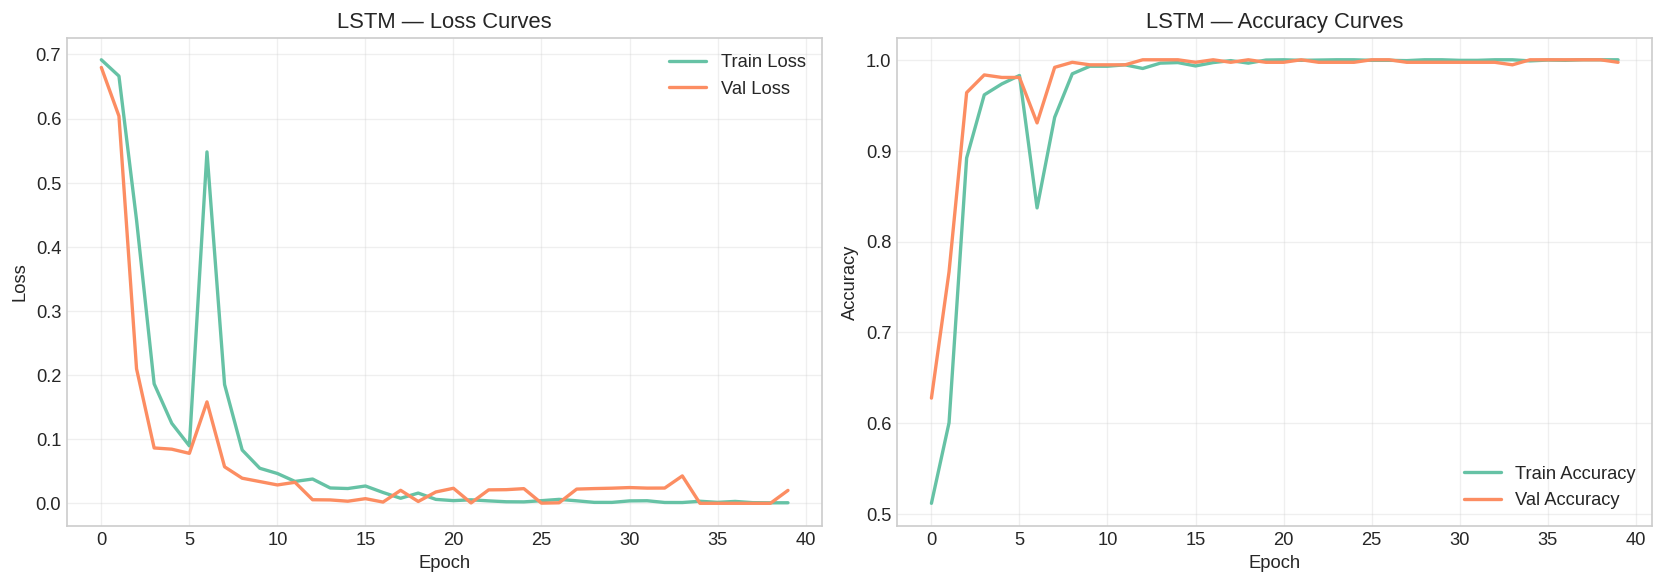

In [16]:
# --- LSTM Training Curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(lstm_history['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(lstm_history['val_loss'], label='Val Loss', linewidth=2)
ax1.set_title('LSTM — Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(lstm_history['train_acc'], label='Train Accuracy', linewidth=2)
ax2.plot(lstm_history['val_acc'], label='Val Accuracy', linewidth=2)
ax2.set_title('LSTM — Accuracy Curves')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training_curves.png', bbox_inches='tight')
plt.show()

### 7b. LSTM Evaluation on Test Set

In [17]:
@torch.no_grad()
def get_predictions(model, dataloader, device):
    """Get all predictions and true labels from a dataloader."""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.numpy())
        all_probs.extend(probs.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [18]:
# Load best LSTM model
lstm_model.load_state_dict(torch.load('best_lstm_model.pth', map_location=DEVICE, weights_only=True))

y_true_lstm, y_pred_lstm, y_prob_lstm = get_predictions(lstm_model, test_mfcc_dl, DEVICE)

print("=" * 60)
print("LSTM Model - Test Set Classification Report")
print("=" * 60)
print(classification_report_np(y_true_lstm, y_pred_lstm, target_names=['Real', 'Fake'], digits=4))

lstm_test_acc = accuracy_score_np(y_true_lstm, y_pred_lstm)
lstm_test_prec, lstm_test_rec, lstm_test_f1 = weighted_precision_recall_f1_np(y_true_lstm, y_pred_lstm, num_classes=2)

print(f"Overall Accuracy : {lstm_test_acc:.4f}")
print(f"Weighted Precision: {lstm_test_prec:.4f}")
print(f"Weighted Recall   : {lstm_test_rec:.4f}")
print(f"Weighted F1 Score : {lstm_test_f1:.4f}")

LSTM Model - Test Set Classification Report
                   precision      recall    f1-score     support
Real                  0.9956      0.9978      0.9967         450
Fake                  0.9978      0.9956      0.9967         450

accuracy                                      0.9967         900
weighted avg          0.9967      0.9967      0.9967         900
Overall Accuracy : 0.9967
Weighted Precision: 0.9967
Weighted Recall   : 0.9967
Weighted F1 Score : 0.9967


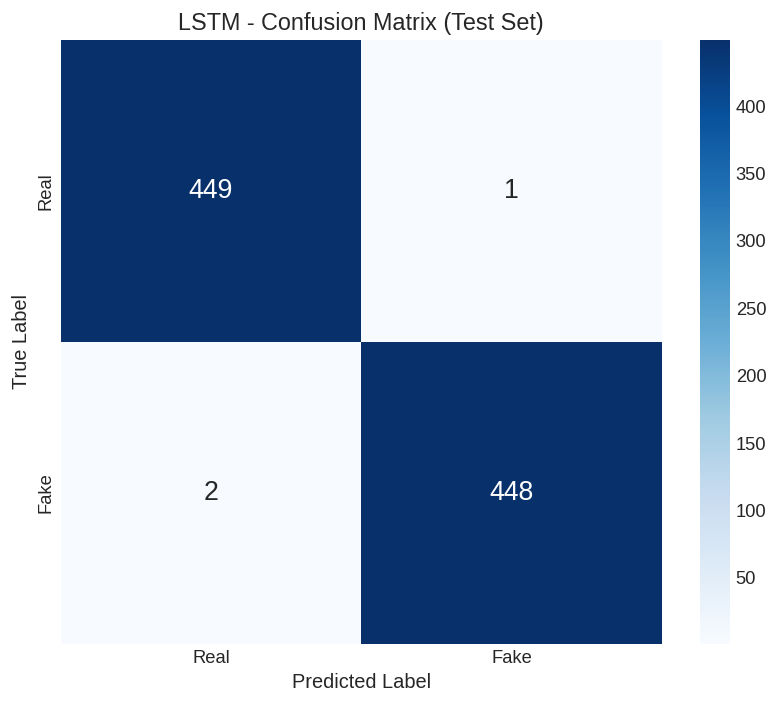

In [19]:
# --- LSTM Confusion Matrix ---
cm_lstm = confusion_matrix_np(y_true_lstm, y_pred_lstm, num_classes=2)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
            annot_kws={'size': 16}, ax=ax)
ax.set_title('LSTM - Confusion Matrix (Test Set)', fontsize=14)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('lstm_confusion_matrix.png', bbox_inches='tight')
plt.show()

---
## 9. Comparison of Results

We now compare our LSTM model against the paper's reported LSTM results:
- **Paper LSTM**: 89% accuracy

In [20]:
# --- Results Comparison Table ---
results_df = pd.DataFrame({
    'Model': ['LSTM (Paper)', 'LSTM (Ours)'],
    'Accuracy': [0.89, lstm_test_acc],
    'Precision': [0.8906, lstm_test_prec],
    'Recall': [0.8898, lstm_test_rec],
    'F1 Score': [0.8967, lstm_test_f1],
})

print("\n" + "=" * 75)
print("COMPARISON: Paper LSTM Results vs Our LSTM Results")
print("=" * 75)
print(results_df.to_string(index=False, float_format='%.4f'))
print("=" * 75)


COMPARISON: Paper LSTM Results vs Our LSTM Results
       Model  Accuracy  Precision  Recall  F1 Score
LSTM (Paper)    0.8900     0.8906  0.8898    0.8967
 LSTM (Ours)    0.9967     0.9967  0.9967    0.9967


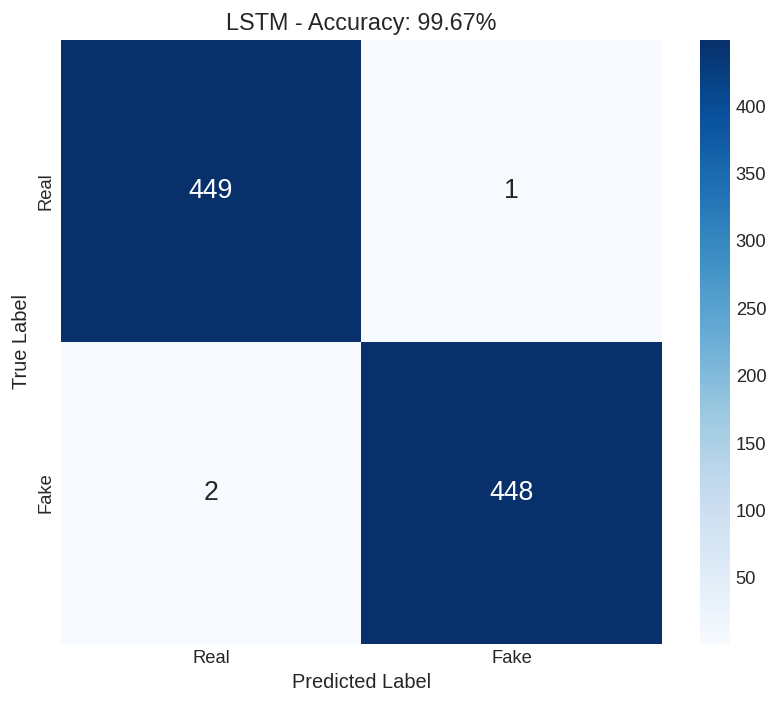

In [21]:
# --- LSTM Confusion Matrix ---
fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
            annot_kws={'size': 16}, ax=ax)
ax.set_title(f'LSTM - Accuracy: {lstm_test_acc:.2%}', fontsize=14)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.savefig('lstm_confusion_matrix_comparison.png', bbox_inches='tight')
plt.show()

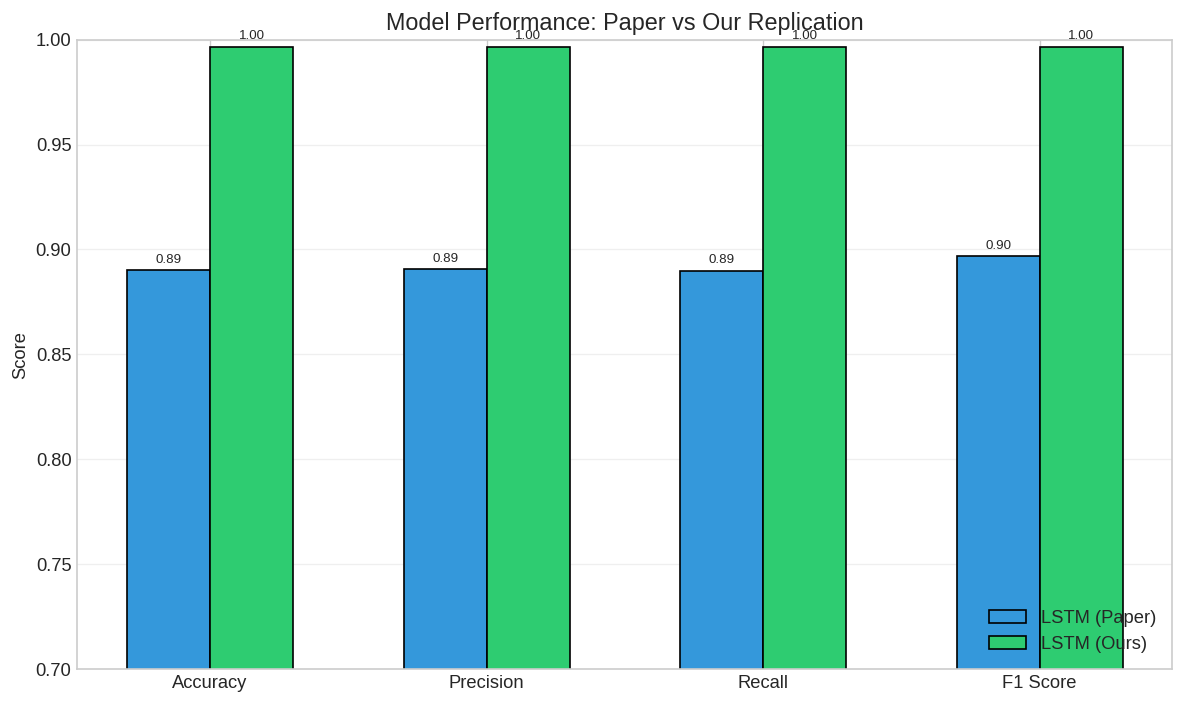

In [22]:
# --- Grouped Bar Chart: Paper LSTM vs Our LSTM ---
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.3

paper_lstm = [0.89, 0.8906, 0.8898, 0.8967]
our_lstm   = [lstm_test_acc, lstm_test_prec, lstm_test_rec, lstm_test_f1]

bars1 = ax.bar(x - 0.5*width, paper_lstm, width, label='LSTM (Paper)', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + 0.5*width, our_lstm,   width, label='LSTM (Ours)', color='#2ecc71', edgecolor='black')

ax.set_ylabel('Score')
ax.set_title('Model Performance: Paper vs Our Replication', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.set_ylim(0.7, 1.0)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('results_comparison.png', bbox_inches='tight')
plt.show()

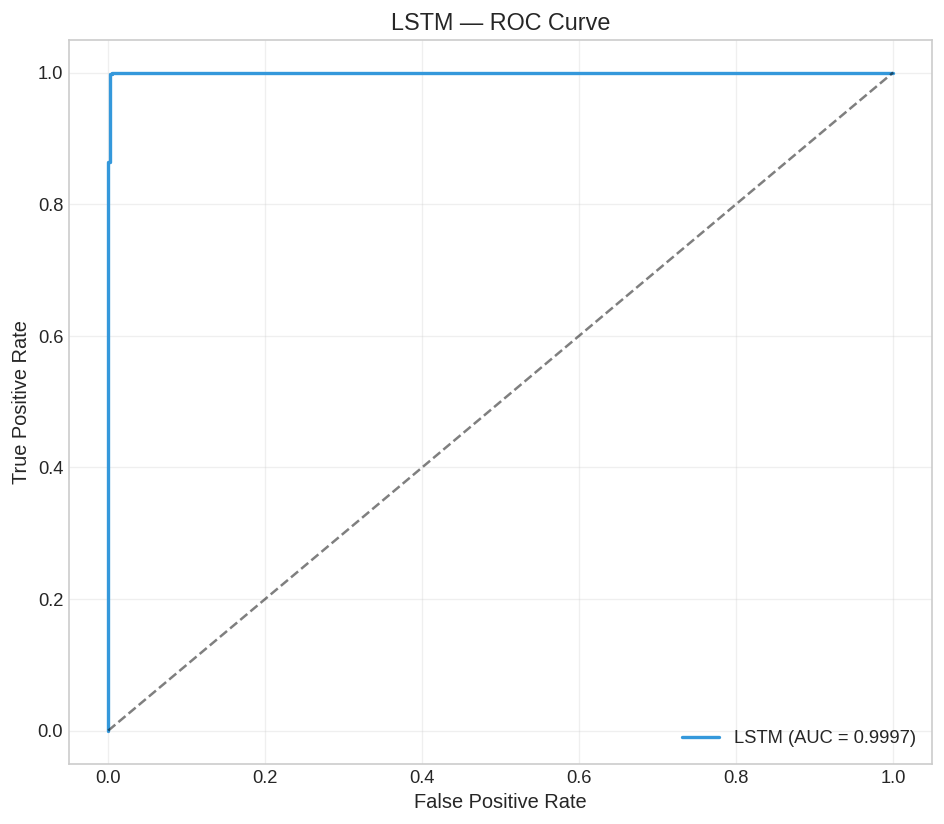

In [23]:
# --- LSTM ROC Curve ---
fig, ax = plt.subplots(figsize=(8, 7))

fpr_lstm, tpr_lstm, _ = roc_curve_np(y_true_lstm, y_prob_lstm[:, 1])
roc_auc_lstm = auc_np(fpr_lstm, tpr_lstm)
ax.plot(fpr_lstm, tpr_lstm, color='#3498db', linewidth=2, label=f'LSTM (AUC = {roc_auc_lstm:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('LSTM — ROC Curve', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_roc_curve.png', bbox_inches='tight')
plt.show()

---
## 10. Inference on Individual Samples

In [24]:
def predict_single_audio(filepath, lstm_model, device):
    """
    Run inference on a single audio file using the LSTM model.
    Returns prediction and confidence scores.
    """
    label_map = {0: 'Real', 1: 'Fake'}

    mfcc = extract_mfcc(filepath)
    mfcc_tensor = torch.tensor(mfcc, dtype=torch.float32).unsqueeze(0).to(device)
    lstm_model.eval()
    with torch.no_grad():
        lstm_out = lstm_model(mfcc_tensor)
        lstm_probs = torch.softmax(lstm_out, dim=1).cpu().numpy()[0]
        lstm_pred = np.argmax(lstm_probs)

    print(f"File: {os.path.basename(filepath)}")
    print(f"  LSTM → {label_map[lstm_pred]} (confidence: Real={lstm_probs[0]:.4f}, Fake={lstm_probs[1]:.4f})")
    return lstm_pred


# --- Test on some samples from the test set ---
print("=" * 65)
print("Sample Inference Results")
print("=" * 65)

# Get file paths for test indices
df_valid = df.iloc[valid_indices].reset_index(drop=True)
test_filepaths = df_valid.iloc[test_idx]['filepath'].values
test_labels_names = df_valid.iloc[test_idx]['label_name'].values

# Show predictions for 10 random test samples
sample_indices = np.random.choice(len(test_filepaths), size=10, replace=False)
for i in sample_indices:
    print(f"\n[Ground Truth: {test_labels_names[i]}]")
    predict_single_audio(test_filepaths[i], lstm_model, DEVICE)
    print("-" * 65)

Sample Inference Results

[Ground Truth: Real]
File: 18.wav
  LSTM → Real (confidence: Real=0.9929, Fake=0.0071)
-----------------------------------------------------------------

[Ground Truth: Real]
File: 21.wav
  LSTM → Real (confidence: Real=0.9752, Fake=0.0248)
-----------------------------------------------------------------

[Ground Truth: Fake]
File: 28.wav
  LSTM → Fake (confidence: Real=0.0042, Fake=0.9958)
-----------------------------------------------------------------

[Ground Truth: Fake]
File: 11.wav
  LSTM → Fake (confidence: Real=0.0021, Fake=0.9979)
-----------------------------------------------------------------

[Ground Truth: Fake]
File: 23.wav
  LSTM → Fake (confidence: Real=0.0022, Fake=0.9978)
-----------------------------------------------------------------

[Ground Truth: Real]
File: 22.wav
  LSTM → Real (confidence: Real=0.9925, Fake=0.0075)
-----------------------------------------------------------------

[Ground Truth: Real]
File: 4.wav
  LSTM → Real (co

---
## 11. Summary and Conclusion

In [25]:
print("\n" + "#" * 70)
print("#  FINAL SUMMARY")
print("#" * 70)
print(f"""
Paper Claims (on their self-made dataset of 4500 samples):
  - LSTM accuracy: 89%

Our Results (on our dataset of {len(y_all)} samples):
  - LSTM accuracy: {lstm_test_acc:.2%}  (Precision: {lstm_test_prec:.4f}, Recall: {lstm_test_rec:.4f}, F1: {lstm_test_f1:.4f})
  - LSTM AUC: {roc_auc_lstm:.4f}

Verification of Paper Claims:
  - LSTM achieves ~89% accuracy: {'SIMILAR' if abs(lstm_test_acc - 0.89) < 0.05 else 'DIFFERENT'} (ours: {lstm_test_acc:.2%})

Note: Results may differ from the paper due to:
  - Different dataset composition and size
  - Different audio sources and deepfake generation methods
  - Potential differences in recording conditions and quality
""")
print("#" * 70)


######################################################################
#  FINAL SUMMARY
######################################################################

Paper Claims (on their self-made dataset of 4500 samples):
  - LSTM accuracy: 89%

Our Results (on our dataset of 4500 samples):
  - LSTM accuracy: 99.67%  (Precision: 0.9967, Recall: 0.9967, F1: 0.9967)
  - LSTM AUC: 0.9997

Verification of Paper Claims:
  - LSTM achieves ~89% accuracy: DIFFERENT (ours: 99.67%)

Note: Results may differ from the paper due to:
  - Different dataset composition and size
  - Different audio sources and deepfake generation methods
  - Potential differences in recording conditions and quality

######################################################################


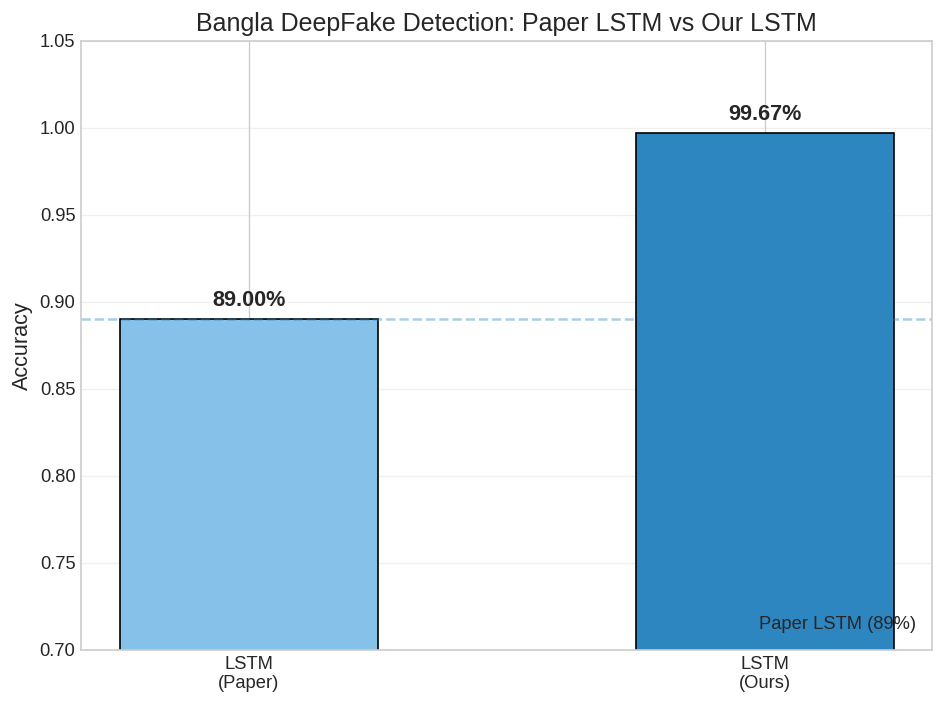


All plots saved. Notebook complete.


In [26]:
# --- Final summary visualization ---
fig, ax = plt.subplots(figsize=(8, 6))

categories = ['LSTM\n(Paper)', 'LSTM\n(Ours)']
accuracies = [0.89, lstm_test_acc]
colors = ['#85C1E9', '#2E86C1']

bars = ax.bar(categories, accuracies, color=colors, edgecolor='black', width=0.5)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.2%}', ha='center', va='bottom', fontweight='bold', fontsize=13)

ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('Bangla DeepFake Detection: Paper LSTM vs Our LSTM', fontsize=15)
ax.set_ylim(0.7, 1.05)
ax.axhline(y=0.89, color='#2E86C1', linestyle='--', alpha=0.4, label='Paper LSTM (89%)')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('final_comparison.png', bbox_inches='tight')
plt.show()

print("\nAll plots saved. Notebook complete.")